# 🎓 Student Performance Prediction
Machine Learning Project

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('students.csv')

data.head()

,study_hours,attendance,assignments,previous_grade,success
0,7,75,2,8,0
1,4,66,12,5,0
2,8,89,16,19,1
3,5,82,0,9,0
4,7,58,5,13,0


In [17]:
# Basic info
data.info()

# Statistics
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     300 non-null    int64
 1   attendance      300 non-null    int64
 2   assignments     300 non-null    int64
 3   previous_grade  300 non-null    int64
 4   success         300 non-null    int64
dtypes: int64(5)
memory usage: 11.8 KB


,study_hours,attendance,assignments,previous_grade,success
count,300.00000,300.000000,300.000000,300.00000,300.000000
mean,4.92000,75.150000,9.280000,12.02000,0.310000
std,2.64896,14.197632,5.882483,4.40427,0.463266
min,1.00000,50.000000,0.000000,5.00000,0.000000
25%,3.00000,62.750000,4.000000,8.00000,0.000000
50%,5.00000,75.000000,10.000000,12.00000,0.000000
75%,7.00000,86.250000,14.000000,16.00000,1.000000
max,9.00000,99.000000,19.000000,19.00000,1.000000


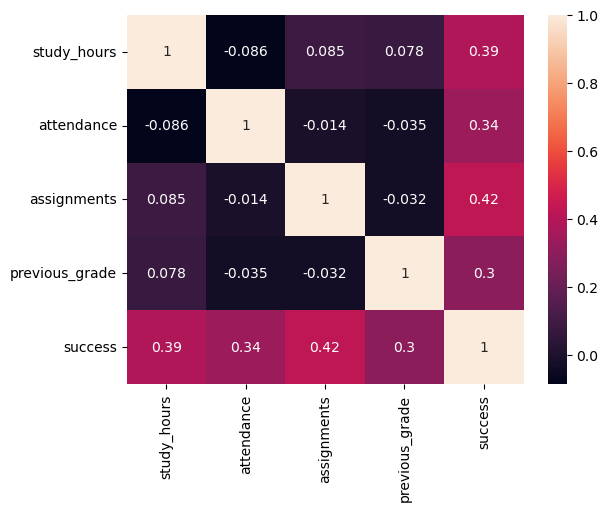

In [19]:
# Correlation heatmap
sns.heatmap(data.corr(), annot=True)
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = data.drop('success', axis=1)
y = data['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        19

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



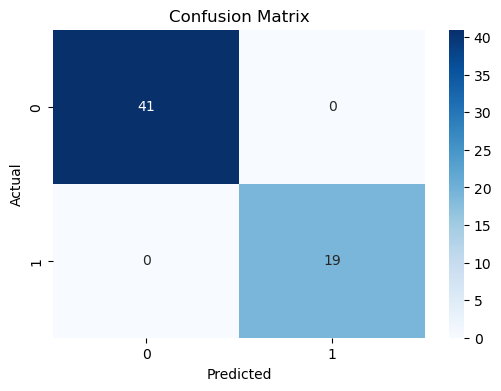

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichage
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
# Feature importance
import pandas as pd

importance = model.feature_importances_
features = X.columns

pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)

,Feature,Importance
2,assignments,0.299760
1,attendance,0.270293
3,previous_grade,0.217452
0,study_hours,0.212494
